# مشروع تحليل بيانات سوق العقارات السكني في المملكة العربية السعودية
## الجزء 1: استيراد وتنظيف البيانات (Data Import & Cleaning) — البيانات الرسمية الفعلية

### مصدر البيانات
**الرقم القياسي لأسعار العقارات (REPI) — الربع الثاني 2026**
الهيئة العامة للإحصاء (GASTAT): [stats.gov.sa/ar/indicators/48](https://www.stats.gov.sa/ar/indicators/48)
الملف الرسمي: `REPI_Q2_2026_AR_EN.xlsx`

**سنة الأساس: 2023 = 100**

### بنية الملف الرسمي (3 جداول بيانات)

| الجدول | المحتوى | التغطية الزمنية |
|---|---|---|
| الجدول 1 | لقطة مقارنة سريعة حسب القطاع/نوع العقار (مع الأوزان النسبية %) | Q2-2025 مقابل Q1-2026 مقابل Q2-2026 |
| الجدول 2 | سلسلة زمنية كاملة حسب **القطاع ونوع العقار** (على مستوى المملكة) | 2021Q1 – 2026Q2 |
| الجدول 3 | سلسلة زمنية كاملة حسب **المنطقة الإدارية** (13 منطقة، كل الأنواع مجمّعة) | 2021Q1 – 2026Q2 |

**ملاحظة منهجية مهمة:** الملف الرسمي **لا يوفر تقاطعاً بين المنطقة ونوع العقار معاً** — أي لا توجد بيانات "أسعار الفلل في الرياض" تحديداً، بل جدولان منفصلان (نوع العقار على مستوى المملكة، والمنطقة على مستوى المملكة لكل الأنواع مجتمعة). هذا القيد سيُؤخذ بعين الاعتبار في تصميم التحليل اللاحق.

## 1. استيراد المكتبات

In [1]:
import pandas as pd
import numpy as np
import openpyxl
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

SOURCE_FILE = '/mnt/user-data/uploads/REPI_Q2_2026_AR_EN__1_.xlsx'


## 2. استخراج الجدول 1: اللقطة المقارنة السريعة (حسب النوع، مع الأوزان)

In [2]:
import pandas as pd
import numpy as np
import openpyxl

wb = openpyxl.load_workbook(SOURCE_FILE, data_only=True)

ws1 = wb['1']
rows1 = list(ws1.iter_rows(min_row=11, max_row=21, values_only=True))

snapshot_records = []
for r in rows1:
    if r[0] is None:
        continue
    snapshot_records.append({
        'category_ar': str(r[0]).strip(),
        'category_en': str(r[7]).strip(),
        'weight_pct': r[1],
        'index_q2_2025': r[2],
        'index_q1_2026': r[3],
        'index_q2_2026': r[4],
        'yoy_change_pct': r[5],
        'qoq_change_pct': r[6],
    })

df_snapshot = pd.DataFrame(snapshot_records)
for col in ['weight_pct', 'index_q2_2025', 'index_q1_2026', 'index_q2_2026',
            'yoy_change_pct', 'qoq_change_pct']:
    df_snapshot[col] = pd.to_numeric(df_snapshot[col], errors='coerce')

df_snapshot.to_csv('repi_latest_snapshot.csv', index=False, encoding='utf-8-sig')
print(f"عدد الفئات: {len(df_snapshot)}")
df_snapshot


عدد الفئات: 11


,category_ar,category_en,weight_pct,index_q2_2025,index_q1_2026,index_q2_2026,yoy_change_pct,qoq_change_pct
0,الرقم القياسي العام,General index,100.000,105.00,103.29,106.34,1.3,3.0
1,سكني,Residential,72.661,101.57,100.55,104.25,2.6,3.7
2,قطعة أرض سكنية,Residential Plot,45.849,101.30,101.46,107.65,6.3,6.1
3,فيلا,Villa,10.455,105.03,96.88,94.89,-9.7,-2.1
4,شقة,Apartment,14.989,100.32,100.49,101.43,1.1,0.9
5,دور,Floor,1.368,98.05,99.49,98.42,0.4,-1.1
6,تجاري,Commercial,25.404,115.69,110.81,111.96,-3.2,1.0
7,قطعة أرض تجارية,Commercial Plot,22.836,116.56,111.23,112.44,-3.5,1.1
8,عمارة,Building,2.015,110.22,109.82,109.52,-0.6,-0.3
9,معرض / محل,Gallery/ Shop,0.553,101.37,98.04,101.74,0.4,3.8


## 3. استخراج الجدول 2: السلسلة الزمنية حسب القطاع ونوع العقار (2021Q1–2026Q2)

بنية الأعمدة في الملف الأصلي: كل فئة (عام / سكني إجمالي / قطعة أرض سكنية / فيلا / شقة / دور / تجاري إجمالي / قطعة أرض تجارية / عمارة / معرض-محل / زراعي إجمالي / أرض زراعية) لها 3 أعمدة متتالية: **المؤشر، التغيّر الربعي %، التغيّر السنوي %**.

In [3]:
import pandas as pd
import numpy as np

ws2 = wb['2']
rows2 = list(ws2.iter_rows(min_row=14, max_row=40, values_only=True))

# تعريف الفئات بالترتيب الفعلي في الملف (كل فئة تشغل 3 أعمدة: مؤشر / ربعي / سنوي)
type_categories = [
    ('عام', 'General'),
    ('إجمالي السكني', 'Total Residential'),
    ('قطعة أرض سكنية', 'Residential Plot'),
    ('فيلا', 'Villa'),
    ('شقة', 'Apartment'),
    ('دور', 'Floor'),
    ('إجمالي التجاري', 'Total Commercial'),
    ('قطعة أرض تجارية', 'Commercial Plot'),
    ('عمارة', 'Building'),
    ('معرض / محل', 'Gallery/Shop'),
    ('إجمالي الزراعي', 'Total Agricultural'),
    ('أرض زراعية', 'Agricultural Land'),
]

type_records = []
for r in rows2:
    if r[0] is None or not str(r[0]).strip().replace('.', '', 1).isdigit():
        continue
    year = int(r[0])
    quarter_ar = r[1]
    quarter_code = r[38]   # 'Q1'..'Q4' أو 'Annual average' لصفوف المتوسط السنوي
    if quarter_code not in ('Q1', 'Q2', 'Q3', 'Q4'):
        continue  # نستبعد صفوف "المتوسط السنوي" ونحتفظ بالأرباع فقط
    col = 2
    for cat_ar, cat_en in type_categories:
        type_records.append({
            'year': year,
            'quarter_code': quarter_code,
            'quarter_period': f"{year}{quarter_code}",
            'category_ar': cat_ar,
            'category_en': cat_en,
            'index_value': r[col],
            'qoq_change_pct': r[col + 1],
            'yoy_change_pct': r[col + 2],
        })
        col += 3

df_type = pd.DataFrame(type_records)
print(f"عدد الصفوف الخام: {len(df_type)}  |  عدد الأرباع: {df_type['quarter_period'].nunique()}  |  عدد الفئات: {df_type['category_ar'].nunique()}")
df_type.head(12)


عدد الصفوف الخام: 264  |  عدد الأرباع: 22  |  عدد الفئات: 12


,year,quarter_code,quarter_period,category_ar,category_en,index_value,qoq_change_pct,yoy_change_pct
0,2021,Q1,2021Q1,عام,General,81.37,-,-
1,2021,Q1,2021Q1,إجمالي السكني,Total Residential,80.78,-,-
2,2021,Q1,2021Q1,قطعة أرض سكنية,Residential Plot,80.60,-,-
3,2021,Q1,2021Q1,فيلا,Villa,77.25,-,-
4,2021,Q1,2021Q1,شقة,Apartment,82.74,-,-
5,2021,Q1,2021Q1,دور,Floor,94.27,-,-
6,2021,Q1,2021Q1,إجمالي التجاري,Total Commercial,82.86,-,-
7,2021,Q1,2021Q1,قطعة أرض تجارية,Commercial Plot,82.84,-,-
8,2021,Q1,2021Q1,عمارة,Building,80.10,-,-
9,2021,Q1,2021Q1,معرض / محل,Gallery/Shop,94.83,-,-


## 4. استخراج الجدول 3: السلسلة الزمنية حسب المنطقة الإدارية (2021Q1–2026Q2)

In [4]:
import pandas as pd
import numpy as np

ws3 = wb['3']
rows3 = list(ws3.iter_rows(min_row=12, max_row=38, values_only=True))

regions = [
    ('عام (المملكة)', 'Kingdom (General)'),
    ('الرياض', 'Riyadh'),
    ('مكة المكرمة', 'Makkah'),
    ('المدينة المنورة', 'Madinah'),
    ('القصيم', 'Al Qaseem'),
    ('المنطقة الشرقية', 'Eastern Province'),
    ('عسير', 'Aseer'),
    ('تبوك', 'Tabouk'),
    ('حائل', 'Hail'),
    ('الحدود الشمالية', 'Northern Borders'),
    ('جازان', 'Jazan'),
    ('نجران', 'Najran'),
    ('الباحة', 'Al Baha'),
    ('الجوف', 'Al Jouf'),
]

region_records = []
for r in rows3:
    if r[0] is None or not str(r[0]).strip().replace('.', '', 1).isdigit():
        continue
    year = int(r[0])
    quarter_code = r[44]
    if quarter_code not in ('Q1', 'Q2', 'Q3', 'Q4'):
        continue
    col = 2
    for reg_ar, reg_en in regions:
        region_records.append({
            'year': year,
            'quarter_code': quarter_code,
            'quarter_period': f"{year}{quarter_code}",
            'region_ar': reg_ar,
            'region_en': reg_en,
            'index_value': r[col],
            'qoq_change_pct': r[col + 1],
            'yoy_change_pct': r[col + 2],
        })
        col += 3

df_region = pd.DataFrame(region_records)
print(f"عدد الصفوف الخام: {len(df_region)}  |  عدد الأرباع: {df_region['quarter_period'].nunique()}  |  عدد المناطق: {df_region['region_ar'].nunique()}")
df_region.head(15)


عدد الصفوف الخام: 308  |  عدد الأرباع: 22  |  عدد المناطق: 14


,year,quarter_code,quarter_period,region_ar,region_en,index_value,qoq_change_pct,yoy_change_pct
0,2021,Q1,2021Q1,عام (المملكة),Kingdom (General),81.37,-,-
1,2021,Q1,2021Q1,الرياض,Riyadh,74.40,-,-
2,2021,Q1,2021Q1,مكة المكرمة,Makkah,86.67,-,-
3,2021,Q1,2021Q1,المدينة المنورة,Madinah,89.15,-,-
4,2021,Q1,2021Q1,القصيم,Al Qaseem,92.11,-,-
5,2021,Q1,2021Q1,المنطقة الشرقية,Eastern Province,89.34,-,-
6,2021,Q1,2021Q1,عسير,Aseer,88.47,-,-
7,2021,Q1,2021Q1,تبوك,Tabouk,91.34,-,-
8,2021,Q1,2021Q1,حائل,Hail,91.63,-,-
9,2021,Q1,2021Q1,الحدود الشمالية,Northern Borders,91.89,-,-


## 5. فحص جودة البيانات (Data Quality Check)

In [5]:
import pandas as pd
import numpy as np

for name, d in [('حسب النوع', df_type), ('حسب المنطقة', df_region)]:
    print(f"--- {name} ---")
    print(f"القيم الناقصة في index_value: {d['index_value'].isna().sum()}")
    print(f"الصفوف المكررة: {d.duplicated(subset=[c for c in d.columns if 'quarter_period' in c or 'category_ar' in c or 'region_ar' in c]).sum()}")
    print()


--- حسب النوع ---
القيم الناقصة في index_value: 0
الصفوف المكررة: 0

--- حسب المنطقة ---
القيم الناقصة في index_value: 0
الصفوف المكررة: 0



## 6. تنظيف نهائي والتحقق من اتساق أنواع البيانات

In [6]:
import pandas as pd
import numpy as np

# التأكد من أن الأعمدة الرقمية بصيغة رقمية سليمة قبل أي عملية حسابية
for d in (df_type, df_region):
    d['index_value'] = pd.to_numeric(d['index_value'], errors='coerce')
    d['qoq_change_pct'] = pd.to_numeric(d['qoq_change_pct'], errors='coerce')
    d['yoy_change_pct'] = pd.to_numeric(d['yoy_change_pct'], errors='coerce')

df_type = df_type.dropna(subset=['index_value']).reset_index(drop=True)
df_region = df_region.dropna(subset=['index_value']).reset_index(drop=True)

# ترتيب زمني منطقي لكل جدول
quarter_order = {'Q1': 1, 'Q2': 2, 'Q3': 3, 'Q4': 4}
for d in (df_type, df_region):
    d['q_num'] = d['quarter_code'].map(quarter_order)
    d.sort_values(['year', 'q_num'], inplace=True)
    d.drop(columns='q_num', inplace=True)

print("✅ df_type:", df_type.shape, "| الأرباع من", df_type['quarter_period'].min(), "إلى", df_type['quarter_period'].max())
print("✅ df_region:", df_region.shape, "| الأرباع من", df_region['quarter_period'].min(), "إلى", df_region['quarter_period'].max())


✅ df_type: (264, 8) | الأرباع من 2021Q1 إلى 2026Q2
✅ df_region: (308, 8) | الأرباع من 2021Q1 إلى 2026Q2


## 7. حفظ البيانات النظيفة

In [7]:
df_type.to_csv('repi_by_type_clean.csv', index=False, encoding='utf-8-sig')
df_region.to_csv('repi_by_region_clean.csv', index=False, encoding='utf-8-sig')
print("تم حفظ: repi_by_type_clean.csv, repi_by_region_clean.csv, repi_latest_snapshot.csv")


تم حفظ: repi_by_type_clean.csv, repi_by_region_clean.csv, repi_latest_snapshot.csv


## 8. لمحة أولى: اتجاه المؤشر العام مقابل السكني (2021Q1–2026Q2)

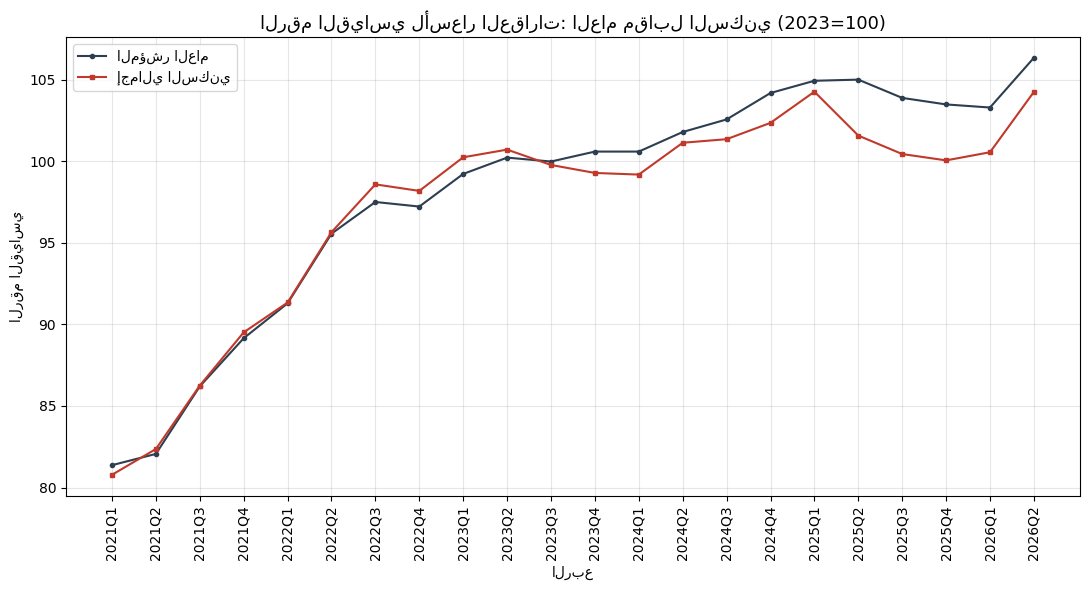

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

general = df_type[df_type['category_ar'] == 'عام'].sort_values('quarter_period') if 'عام' in df_type['category_ar'].values else df_type[df_type['category_ar'].str.contains('عام')].sort_values('quarter_period')
residential = df_type[df_type['category_ar'] == 'إجمالي السكني'].sort_values('quarter_period')

fig, ax = plt.subplots()
ax.plot(general['quarter_period'], general['index_value'], marker='o', markersize=3, label='المؤشر العام', color='#2c3e50')
ax.plot(residential['quarter_period'], residential['index_value'], marker='s', markersize=3, label='إجمالي السكني', color='#c0392b')
ax.set_title('الرقم القياسي لأسعار العقارات: العام مقابل السكني (2023=100)', fontsize=13)
ax.set_xlabel('الربع')
ax.set_ylabel('الرقم القياسي')
ax.tick_params(axis='x', rotation=90)
ax.legend()
plt.tight_layout()
plt.savefig('preview_general_vs_residential.png', dpi=150)
plt.show()


---
### الخطوة التالية

الجزء 2 من المشروع: التحليل الاستكشافي الكامل (EDA) على البيانات الرسمية — ترتيب المناطق حسب أداء المؤشر، مقارنة أنواع العقار (أراضٍ سكنية/فلل/شقق)، تحليل الموسمية الربعية، ثم الانتقال إلى نموذج تنبؤي أولي.